In [1]:
# Cell 0: Setup
!pip install -q optuna openpyxl

import os, sys, gc, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import optuna
from optuna.samplers import GridSampler

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# --- Google Drive 마운트 (Colab only) ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print('✓ Google Drive 마운트 완료')
except:
    IN_COLAB = False
    print('✓ 로컬 환경에서 실행 중')

# --- 경로 설정 ---
if IN_COLAB:
    REPO_PATH = '/content/drive/MyDrive/imbalanced-data-LWCE'
    DATA_PATH = '/content/drive/MyDrive/imbalanced loss project/data'
else:
    REPO_PATH = 'C:/Users/Seung/Desktop/Research/Deep_Learning/imbalanced-data-LWCE'
    DATA_PATH = f'{REPO_PATH}/tabular_data/data'

RESULTS_DIR = f'{REPO_PATH}/tabular_data/results/mlp'
os.makedirs(RESULTS_DIR, exist_ok=True)

SCR_PATH     = f'{REPO_PATH}/tabular_data/scr'
IMG_CLF_PATH = f'{REPO_PATH}/image_classification'

for p in [SCR_PATH, IMG_CLF_PATH]:
    if p not in sys.path:
        sys.path.insert(0, p)

try:
    from data_handler import load_dataset
    from custom_losses import get_clf_loss
    print(f'✓ 모듈 로드 성공')
    print(f'  scr 경로: {SCR_PATH}')
except ModuleNotFoundError as e:
    print(f'⚠️  모듈 로드 실패: {e}')
    print(f'  확인: Drive에 {SCR_PATH}/data_handler.py 파일이 있는지 확인하세요')
    raise

# --- Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Device: {device}')
if torch.cuda.is_available():
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

# --- 상수 ---
DATASETS = [
    'credit_card_fraud', 'aps_failure', 'bank_marketing', 'telco_churn',
    'german_credit', 'secom', 'credit_card_default',
    'glass', 'steel_faults', 'yeast', 'page_blocks',
]
LOSS_CONFIGS = ['ce', 'pwce', 'sqce', 'lwce', 'plwce', 'cb', 'focal']  # CIFAR 실험 + sqce(sqrt-CE) 7종
SEEDS        = [42, 43, 44, 45, 46]

BATCH_SIZE   = 512
FINAL_EPOCHS = 100   # 50→100: 소규모 데이터셋 수렴 보장
PROXY_EPOCHS = 20
PROXY_RATIO  = 0.20
N_PWCE       = 30
N_PLWCE      = 30
N_FOCAL      = 30

print(f'\n✓ 환경 설정 완료')
print(f'  총 실험 수: {len(DATASETS)} datasets × {len(LOSS_CONFIGS)} losses × {len(SEEDS)} seeds = {len(DATASETS)*len(LOSS_CONFIGS)*len(SEEDS)} runs')

Mounted at /content/drive
✓ Google Drive 마운트 완료
✓ 모듈 로드 성공
  scr 경로: /content/drive/MyDrive/imbalanced-data-LWCE/tabular_data/scr
✓ Device: cuda
  GPU: Tesla T4

✓ 환경 설정 완료
  총 실험 수: 11 datasets × 7 losses × 5 seeds = 385 runs


In [2]:
# Cell 1: Data loading
raw_data = {}

for ds in DATASETS:
    X_tr, X_te, y_tr, y_te = load_dataset(ds, DATA_PATH, test_size=0.3, random_state=42)

    X_tr = (X_tr.values if hasattr(X_tr, 'values') else X_tr).astype(np.float32)
    X_te = (X_te.values if hasattr(X_te, 'values') else X_te).astype(np.float32)
    y_tr = np.array(y_tr, dtype=np.int64)
    y_te = np.array(y_te, dtype=np.int64)

    # remap labels to 0..C-1 (handles gaps like glass {0,1,2,3,4,6})
    unique = np.unique(y_tr)
    if not np.array_equal(unique, np.arange(len(unique))):
        remap = {v: i for i, v in enumerate(unique)}
        y_tr = np.array([remap[v] for v in y_tr], dtype=np.int64)
        y_te = np.array([remap[v] for v in y_te], dtype=np.int64)

    num_classes  = len(np.unique(y_tr))
    class_counts = [int((y_tr == c).sum()) for c in range(num_classes)]
    ir = max(class_counts) / max(min(class_counts), 1)

    raw_data[ds] = (X_tr, X_te, y_tr, y_te, class_counts, num_classes)
    print(f'{ds:25s}  feat={X_tr.shape[1]:4d}  C={num_classes:2d}  '
          f'train={len(y_tr):6d}  IR={ir:8.1f}')

credit_card_fraud          feat=  29  C= 2  train=199364  IR=   578.5
aps_failure                feat= 170  C= 2  train= 60000  IR=    59.0
bank_marketing             feat=  42  C= 2  train= 31647  IR=     7.5
telco_churn                feat=  30  C= 2  train=  4930  IR=     2.8
german_credit              feat=  48  C= 2  train=   700  IR=     2.3
secom                      feat= 590  C= 2  train=  1096  IR=    14.0
credit_card_default        feat=  33  C= 2  train= 21000  IR=     3.5
glass                      feat=   9  C= 6  train=   149  IR=     8.8
steel_faults               feat=  27  C= 7  train=  1358  IR=    12.4
yeast                      feat=   8  C=10  train=  1038  IR=   108.0
page_blocks                feat=  10  C= 5  train=  3831  IR=   171.9


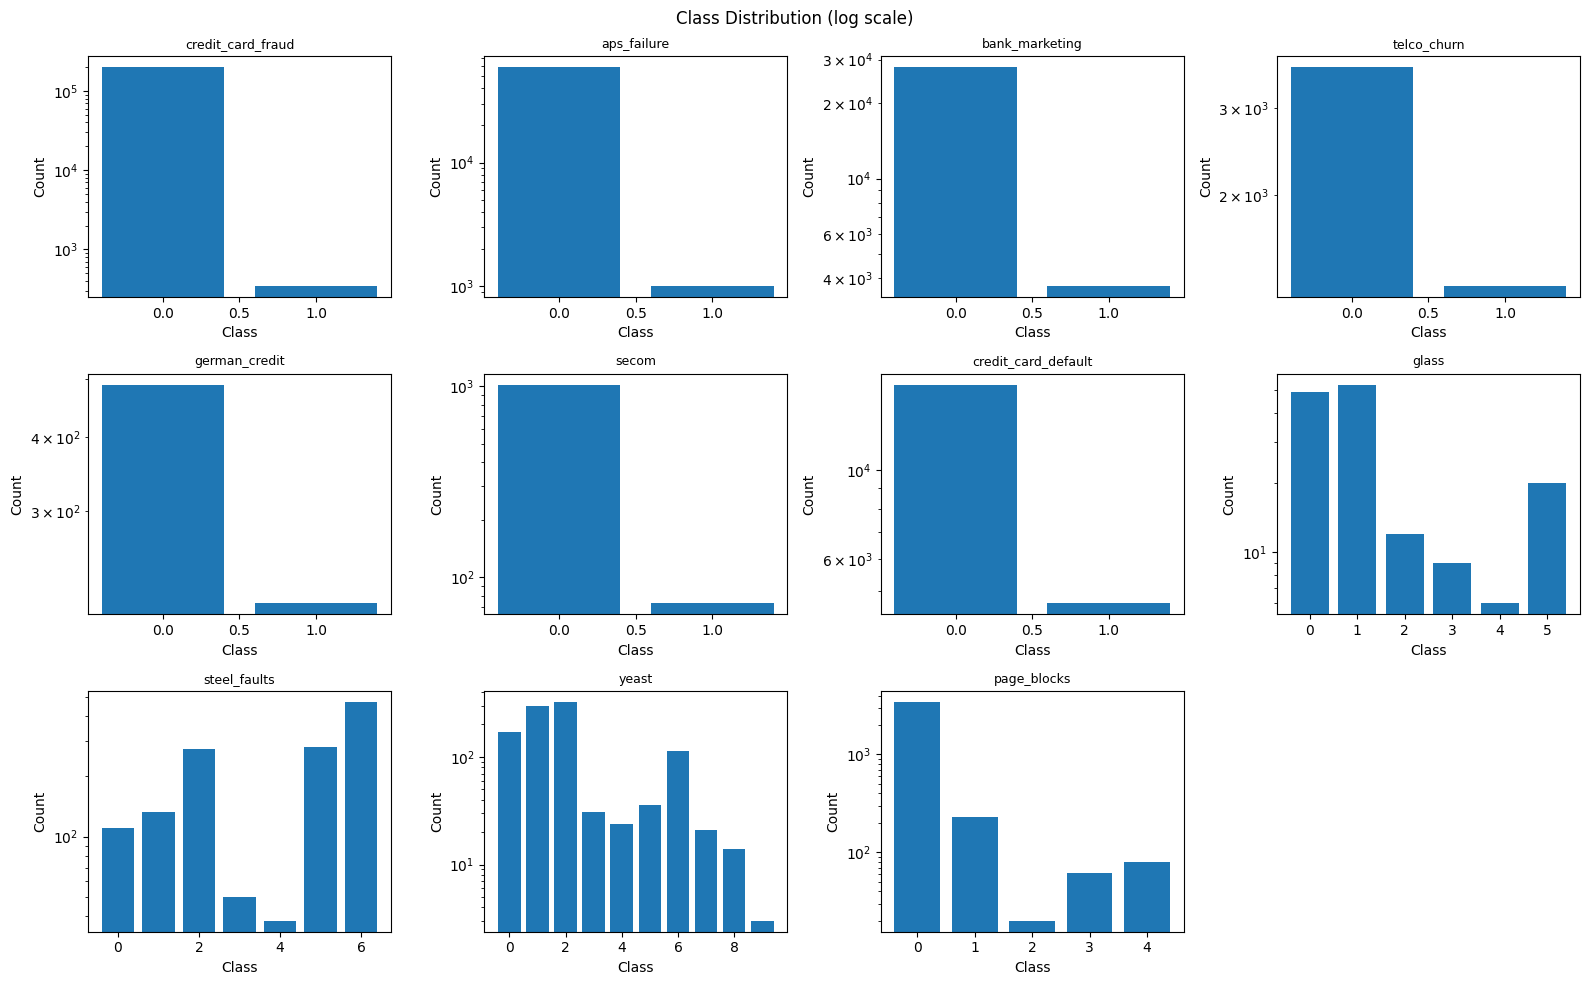

In [3]:
# Cell 2: Class distribution visualization
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, ds in enumerate(DATASETS):
    _, _, _, _, class_counts, _ = raw_data[ds]
    ax = axes[idx]
    ax.bar(range(len(class_counts)), class_counts)
    ax.set_yscale('log')
    ax.set_title(ds, fontsize=9)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')

for i in range(len(DATASETS), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Class Distribution (log scale)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 3: MLP model + metrics

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes, hidden=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers, in_dim = [], input_dim
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def compute_metrics(y_true, y_pred, class_counts):
    acc   = accuracy_score(y_true, y_pred)
    bacc  = balanced_accuracy_score(y_true, y_pred)
    f1m   = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1w   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_pc = f1_score(y_true, y_pred, average=None,       zero_division=0).tolist()

    n   = len(class_counts)
    idx = np.argsort(class_counts)  # minority -> majority
    f1a = np.array(f1_pc)

    if n == 2:
        tail_f1 = float(f1a[idx[0]])
        head_f1 = float(f1a[idx[1]])
        mid_f1  = float(f1m)
    else:
        t       = max(1, n // 3)
        tail_f1 = float(f1a[idx[:t]].mean())
        mid_f1  = float(f1a[idx[t:2*t]].mean()) if 2 * t <= n else tail_f1
        head_f1 = float(f1a[idx[2*t:]].mean())  if 2 * t < n  else float(f1a[idx[-t:]].mean())

    return dict(Accuracy=acc, Balanced_Accuracy=bacc,
                F1_Macro=f1m, F1_Weighted=f1w,
                Per_Class_F1=f1_pc,
                Head_F1=head_f1, Mid_F1=mid_f1, Tail_F1=tail_f1)

In [ ]:
# Cell 4: train_model (definition only — do not execute model here)

def train_model(X_tr, y_tr, X_te, y_te, class_counts, num_classes,
                loss_name, alpha=1.0, gamma=2.0, epochs=100, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

    tr_ld = DataLoader(
        TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
        batch_size=min(BATCH_SIZE, len(X_tr)), shuffle=True, num_workers=0)
    te_ld = DataLoader(
        TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te)),
        batch_size=2048, shuffle=False, num_workers=0)

    model     = MLP(X_tr.shape[1], num_classes).to(device)
    criterion = get_clf_loss(loss_name, class_counts, alpha=alpha, gamma=gamma).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=epochs, eta_min=1e-5)

    for _ in range(epochs):
        model.train()
        for xb, yb in tr_ld:
            optimizer.zero_grad()
            criterion(model(xb.to(device)), yb.to(device)).backward()
            optimizer.step()
        scheduler.step()

    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in te_ld:
            preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
    y_pred = np.concatenate(preds)

    metrics = compute_metrics(y_te, y_pred, class_counts)
    del model, criterion, optimizer
    gc.collect()
    torch.cuda.empty_cache()
    return metrics

In [6]:
# Cell 5: Optuna alpha/gamma search
os.environ['TQDM_DISABLE'] = '1'
best_params = {}


def proxy_score(X_ptr, y_ptr, X_pval, y_pval, class_counts, num_classes,
               loss_name, alpha, gamma):
    torch.manual_seed(42)
    model = MLP(X_ptr.shape[1], num_classes).to(device)
    crit  = get_clf_loss(loss_name, class_counts, alpha=alpha, gamma=gamma).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    ld    = DataLoader(
        TensorDataset(torch.from_numpy(X_ptr), torch.from_numpy(y_ptr)),
        batch_size=min(BATCH_SIZE, len(X_ptr)), shuffle=True, num_workers=0)
    model.train()
    for _ in range(PROXY_EPOCHS):
        for xb, yb in ld:
            opt.zero_grad()
            crit(model(xb.to(device)), yb.to(device)).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(X_pval).to(device)).argmax(1).cpu().numpy()
    score = f1_score(y_pval, preds, average='macro', zero_division=0)
    del model, crit, opt
    gc.collect()
    torch.cuda.empty_cache()
    return score


def make_obj(loss_name, param, grid, X_ptr, y_ptr, X_pval, y_pval, cc, nc):
    def objective(trial):
        v = trial.suggest_float(param, grid[0], grid[-1])
        a, g = (v, 2.0) if param == 'alpha' else (1.0, v)
        return proxy_score(X_ptr, y_ptr, X_pval, y_pval, cc, nc, loss_name, a, g)
    return objective


for ds in DATASETS:
    X_tr, X_te, y_tr, y_te, class_counts, num_classes = raw_data[ds]
    print(f'\nOptuna: {ds}')

    n_proxy = int(PROXY_RATIO * len(X_tr))
    try:
        proxy_idx, _ = train_test_split(
            np.arange(len(X_tr)), train_size=n_proxy, stratify=y_tr, random_state=42)
    except ValueError:
        proxy_idx = np.random.RandomState(42).choice(len(X_tr), n_proxy, replace=False)

    try:
        ptr_idx, pval_idx = train_test_split(
            proxy_idx, test_size=0.2, stratify=y_tr[proxy_idx], random_state=42)
    except ValueError:
        split = int(0.8 * len(proxy_idx))
        ptr_idx, pval_idx = proxy_idx[:split], proxy_idx[split:]

    X_ptr, y_ptr   = X_tr[ptr_idx],  y_tr[ptr_idx]
    X_pval, y_pval = X_tr[pval_idx], y_tr[pval_idx]
    bp = {}

    # PWCE alpha
    ag = np.linspace(0.3, 5.0, N_PWCE).tolist()
    s  = optuna.create_study(direction='maximize', sampler=GridSampler({'alpha': ag}))
    s.optimize(make_obj('pwce', 'alpha', ag, X_ptr, y_ptr, X_pval, y_pval,
                        class_counts, num_classes), n_trials=N_PWCE)
    bp['pwce_alpha'] = s.best_params['alpha']
    print(f'  pwce  alpha={bp["pwce_alpha"]:.3f}  F1={s.best_value:.4f}')

    # PLWCE alpha
    pg = np.linspace(0.5, 6.0, N_PLWCE).tolist()
    s2 = optuna.create_study(direction='maximize', sampler=GridSampler({'alpha': pg}))
    s2.optimize(make_obj('plwce', 'alpha', pg, X_ptr, y_ptr, X_pval, y_pval,
                         class_counts, num_classes), n_trials=N_PLWCE)
    bp['plwce_alpha'] = s2.best_params['alpha']
    print(f'  plwce alpha={bp["plwce_alpha"]:.3f}  F1={s2.best_value:.4f}')

    # Focal gamma
    gg = np.linspace(1.0, 5.0, N_FOCAL).tolist()
    s3 = optuna.create_study(direction='maximize', sampler=GridSampler({'gamma': gg}))
    s3.optimize(make_obj('focal', 'gamma', gg, X_ptr, y_ptr, X_pval, y_pval,
                         class_counts, num_classes), n_trials=N_FOCAL)
    bp['focal_gamma'] = s3.best_params['gamma']
    print(f'  focal gamma={bp["focal_gamma"]:.3f}  F1={s3.best_value:.4f}')

    best_params[ds] = bp

print('\nOptuna search complete.')


Optuna: credit_card_fraud
  pwce  alpha=0.300  F1=0.9061
  plwce alpha=0.879  F1=0.9284
  focal gamma=2.793  F1=0.9615

Optuna: aps_failure
  pwce  alpha=0.300  F1=0.8546
  plwce alpha=0.879  F1=0.8681
  focal gamma=3.345  F1=0.8777

Optuna: bank_marketing
  pwce  alpha=0.300  F1=0.7453
  plwce alpha=3.155  F1=0.7465
  focal gamma=2.241  F1=0.7461

Optuna: telco_churn
  pwce  alpha=0.624  F1=0.7253
  plwce alpha=4.293  F1=0.7300
  focal gamma=1.276  F1=0.7137

Optuna: german_credit
  pwce  alpha=0.786  F1=0.5902
  plwce alpha=3.914  F1=0.6494
  focal gamma=1.000  F1=0.6040

Optuna: secom
  pwce  alpha=1.597  F1=0.5471
  plwce alpha=0.879  F1=0.4699
  focal gamma=4.862  F1=0.4824

Optuna: credit_card_default
  pwce  alpha=0.624  F1=0.7053
  plwce alpha=5.052  F1=0.7019
  focal gamma=2.517  F1=0.7066

Optuna: glass
  pwce  alpha=0.300  F1=0.2600
  plwce alpha=0.500  F1=0.2917
  focal gamma=1.276  F1=0.2917

Optuna: steel_faults
  pwce  alpha=0.786  F1=0.5820
  plwce alpha=2.966  F1=0.58

In [7]:
# Cell 6: Full experiments (6 losses x 11 datasets x 5 seeds)
all_results = []
CKPT_PATH = f'{RESULTS_DIR}/_checkpoint.json'

for ds in DATASETS:
    X_tr, X_te, y_tr, y_te, class_counts, num_classes = raw_data[ds]
    bp = best_params.get(ds, {})

    loss_kwargs = {
        'ce':    {'alpha': 1.0,                        'gamma': 2.0},
        'pwce':  {'alpha': bp.get('pwce_alpha',  1.0), 'gamma': 2.0},
        'sqce':  {'alpha': 0.5,                        'gamma': 2.0},
        'lwce':  {'alpha': 1.0,                        'gamma': 2.0},
        'plwce': {'alpha': bp.get('plwce_alpha', 1.0), 'gamma': 2.0},
        'cb':    {'alpha': 1.0,                        'gamma': 2.0},
        'focal': {'alpha': 1.0,                        'gamma': bp.get('focal_gamma', 2.0)},
    }

    ds_json = f'{RESULTS_DIR}/{ds}_results.json'
    ds_rows = json.load(open(ds_json)) if os.path.exists(ds_json) else []
    done = {(r['Loss'], r['Seed']) for r in ds_rows}
    for loss in LOSS_CONFIGS:
        new_run = False
        for seed in SEEDS:
            if (loss, seed) in done:
                continue
            m = train_model(X_tr, y_tr, X_te, y_te, class_counts, num_classes,
                            loss_name=loss,
                            alpha=loss_kwargs[loss]['alpha'],
                            gamma=loss_kwargs[loss]['gamma'],
                            epochs=FINAL_EPOCHS, seed=seed)
            row = dict(Dataset=ds, Loss=loss, Seed=seed,
                       Accuracy=m['Accuracy'],
                       Balanced_Accuracy=m['Balanced_Accuracy'],
                       F1_Macro=m['F1_Macro'],
                       F1_Weighted=m['F1_Weighted'],
                       Head_F1=m['Head_F1'],
                       Mid_F1=m['Mid_F1'],
                       Tail_F1=m['Tail_F1'])
            ds_rows.append(row)
            new_run = True

        loss_f1s = [r['F1_Macro'] for r in ds_rows if r['Loss'] == loss]
        print(f'{ds:25s}  {loss:6s}  '
              f'F1={np.mean(loss_f1s):.4f}±{np.std(loss_f1s):.4f}  '
              f'Tail={np.mean([r["Tail_F1"] for r in ds_rows if r["Loss"]==loss]):.4f}'
              f'{"" if new_run else "  (cached)"}')

        # (dataset, loss) 완료 시마다 저장 — 중단 시 손실 최소화
        if new_run:
            with open(ds_json, 'w') as f:
                json.dump(ds_rows, f, indent=2)
    all_results.extend(ds_rows)
    with open(CKPT_PATH, 'w') as f:
        json.dump(all_results, f, indent=2)

print('\nAll experiments complete.')

credit_card_fraud          ce      F1=0.9088±0.0040  Tail=0.8179  (cached)
credit_card_fraud          pwce    F1=0.9010±0.0023  Tail=0.8022  (cached)
credit_card_fraud          sqce    F1=0.8723±0.0063  Tail=0.7450
credit_card_fraud          lwce    F1=0.9075±0.0034  Tail=0.8153  (cached)
credit_card_fraud          plwce   F1=0.9097±0.0046  Tail=0.8197
credit_card_fraud          cb      F1=0.8615±0.0045  Tail=0.7236
credit_card_fraud          focal   F1=0.9039±0.0026  Tail=0.8082
aps_failure                ce      F1=0.9025±0.0035  Tail=0.8091
aps_failure                pwce    F1=0.9076±0.0038  Tail=0.8193
aps_failure                sqce    F1=0.9075±0.0037  Tail=0.8192
aps_failure                lwce    F1=0.9062±0.0079  Tail=0.8164
aps_failure                plwce   F1=0.9063±0.0054  Tail=0.8166
aps_failure                cb      F1=0.9048±0.0017  Tail=0.8140
aps_failure                focal   F1=0.8974±0.0030  Tail=0.7990
bank_marketing             ce      F1=0.7689±0.0007  Tail=0.

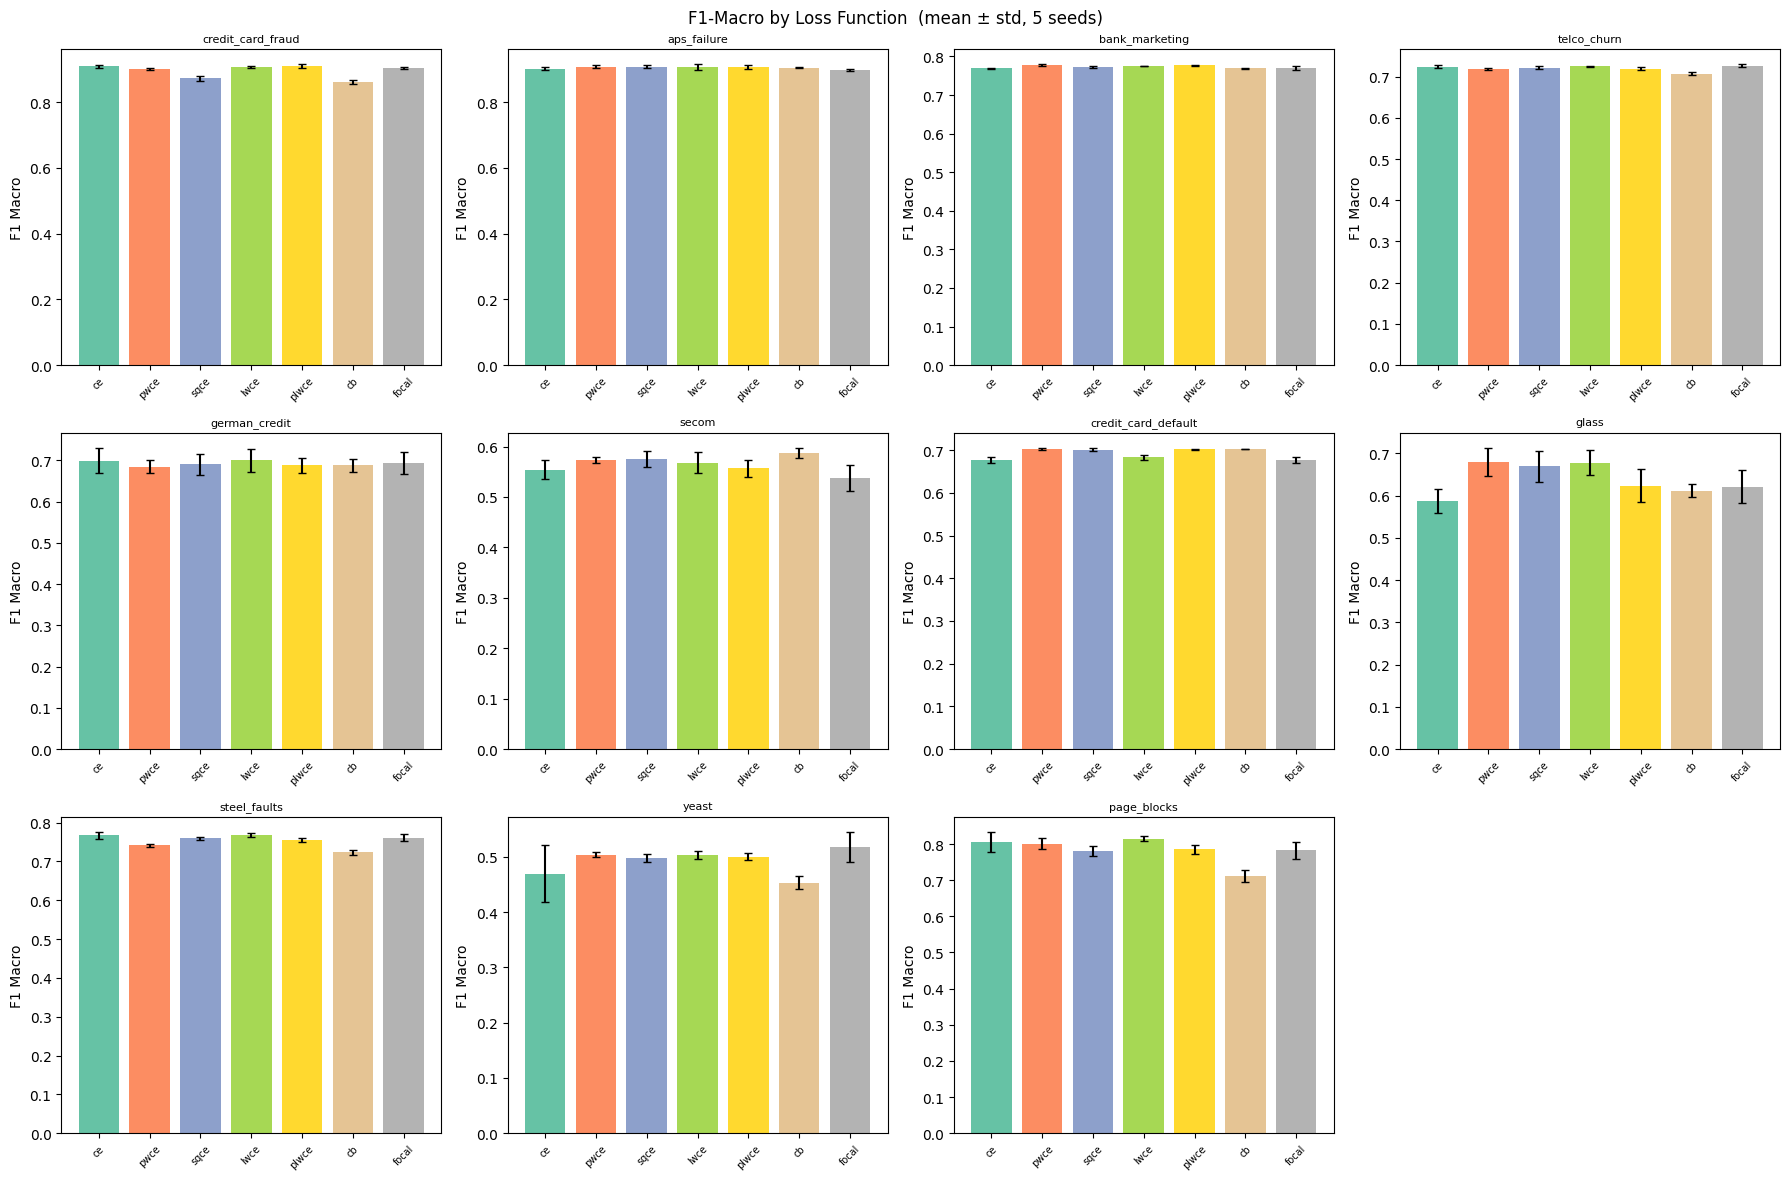

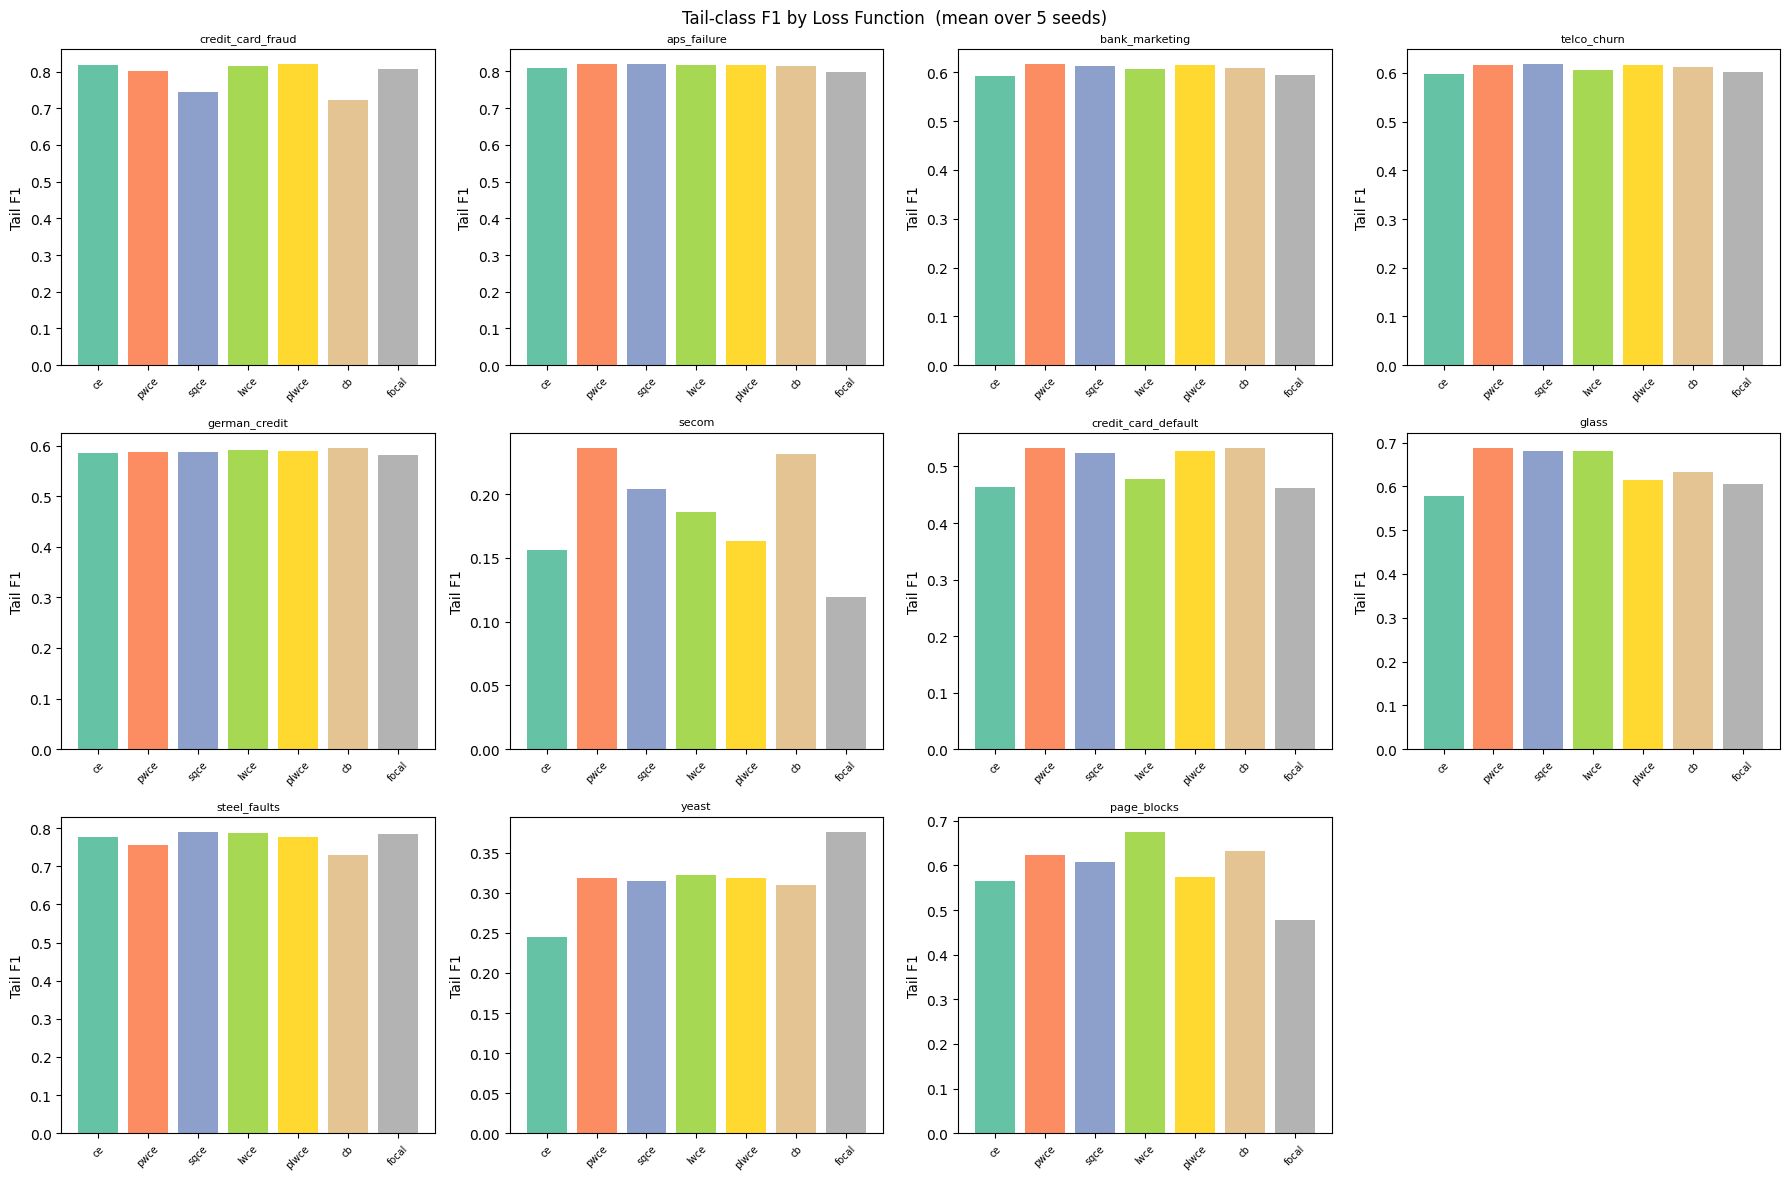

Loss                    ce   pwce   sqce   lwce  plwce     cb  focal
Dataset                                                             
aps_failure         0.9025 0.9076 0.9075 0.9062 0.9063 0.9048 0.8974
bank_marketing      0.7689 0.7778 0.7727 0.7753 0.7767 0.7695 0.7704
credit_card_default 0.6764 0.7026 0.7010 0.6829 0.7017 0.7027 0.6762
credit_card_fraud   0.9088 0.9010 0.8723 0.9075 0.9097 0.8615 0.9039
german_credit       0.6984 0.6848 0.6900 0.6994 0.6875 0.6876 0.6928
glass               0.5868 0.6794 0.6688 0.6775 0.6227 0.6115 0.6211
page_blocks         0.8050 0.8006 0.7808 0.8142 0.7860 0.7115 0.7822
secom               0.5544 0.5727 0.5754 0.5676 0.5567 0.5867 0.5374
steel_faults        0.7671 0.7413 0.7600 0.7684 0.7556 0.7236 0.7615
telco_churn         0.7234 0.7177 0.7218 0.7246 0.7187 0.7068 0.7264
yeast               0.4694 0.5035 0.4981 0.5031 0.5006 0.4531 0.5174

Saved: /content/drive/MyDrive/imbalanced-data-LWCE/tabular_data/results/mlp/mlp_results.xlsx
Saved: /c

In [8]:
# Cell 7: Visualization + save
results_df = pd.DataFrame(all_results)

agg = results_df.groupby(['Dataset', 'Loss']).agg(
    F1_Macro_mean        =('F1_Macro',          'mean'),
    F1_Macro_std         =('F1_Macro',          'std'),
    Balanced_Acc_mean    =('Balanced_Accuracy', 'mean'),
    Tail_F1_mean         =('Tail_F1',           'mean'),
    Head_F1_mean         =('Head_F1',           'mean'),
    F1_Weighted_mean     =('F1_Weighted',       'mean'),
).reset_index()

colors = plt.cm.Set2(np.linspace(0, 1, len(LOSS_CONFIGS)))

# F1-Macro comparison
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for idx, ds in enumerate(DATASETS):
    ax  = axes[idx]
    sub = agg[agg['Dataset'] == ds].set_index('Loss')
    means = [sub.loc[l, 'F1_Macro_mean'] if l in sub.index else 0 for l in LOSS_CONFIGS]
    stds  = [sub.loc[l, 'F1_Macro_std']  if l in sub.index else 0 for l in LOSS_CONFIGS]
    ax.bar(LOSS_CONFIGS, means, yerr=stds, color=colors, capsize=3)
    ax.set_title(ds, fontsize=8)
    ax.set_ylabel('F1 Macro')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
for i in range(len(DATASETS), len(axes)):
    axes[i].set_visible(False)
plt.suptitle('F1-Macro by Loss Function  (mean \u00b1 std, 5 seeds)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/f1_macro_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# Tail-F1 comparison
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for idx, ds in enumerate(DATASETS):
    ax  = axes[idx]
    sub = agg[agg['Dataset'] == ds].set_index('Loss')
    vals = [sub.loc[l, 'Tail_F1_mean'] if l in sub.index else 0 for l in LOSS_CONFIGS]
    ax.bar(LOSS_CONFIGS, vals, color=colors)
    ax.set_title(ds, fontsize=8)
    ax.set_ylabel('Tail F1')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
for i in range(len(DATASETS), len(axes)):
    axes[i].set_visible(False)
plt.suptitle('Tail-class F1 by Loss Function  (mean over 5 seeds)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/tail_f1_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary pivot table
pivot = agg.pivot_table(index='Dataset', columns='Loss', values='F1_Macro_mean')
print(pivot[LOSS_CONFIGS].to_string(float_format='{:.4f}'.format))

# Save Excel
excel_path = f'{RESULTS_DIR}/mlp_results.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    agg.to_excel(writer, sheet_name='Summary', index=False)
    results_df.to_excel(writer, sheet_name='All_Runs', index=False)
    pd.DataFrame(best_params).T.to_excel(writer, sheet_name='Best_Params')

# Save combined JSON
with open(f'{RESULTS_DIR}/mlp_all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print(f'\nSaved: {excel_path}')
print(f'Saved: {RESULTS_DIR}/mlp_all_results.json')